# Statistical Significance Analysis
**Bootstrap-Konfidenzintervalle und Paired t-Tests auf den 2006 Test-Samples**

Addresses Reviewer 3: per-case metrics enable paired significance tests between architectures.
All comparisons are within model size (8B vs 8B, 3B vs 3B).

In [10]:
import json
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)

## 1. Load Per-Case Metrics

In [11]:
import os

BASE = os.path.dirname(os.path.abspath('statistical_analysis.ipynb'))

BENCHMARK_FILES = {
    'Single-8B':  os.path.join(BASE, 'single_agent/benchmark_results/hima_single_benchmark_n0.json'),
    'Multi-8B':   os.path.join(BASE, 'multi_agents/benchmark_results/hima_multi_benchmark_n0.json'),
    'Swarm-8B':   os.path.join(BASE, 'swarm_agents/benchmark_results/hima_swarm_benchmark_n0.json'),
    'Single-3B':  os.path.join(BASE, 'single_agent_small/benchmark_results/hima_single_benchmark_n0.json'),
    'Multi-3B':   os.path.join(BASE, 'multi_agents_small/benchmark_results/hima_multi_small_benchmark_n0.json'),
    'Swarm-3B':   os.path.join(BASE, 'swarm_agents_small/benchmark_results/hima_swarm_small_benchmark_n0.json'),
}

def extract_per_sample(path):
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for s in data['per_sample']:
        # Single-agent uses 'rouge'/'bertscore'; multi/swarm use 'rouge_combined'/'bertscore_combined'
        rouge = s.get('rouge_combined', s.get('rouge'))
        bert  = s.get('bertscore_combined', s.get('bertscore'))
        rows.append({
            'rouge1':    rouge['rouge1']['fmeasure'],
            'rouge2':    rouge['rouge2']['fmeasure'],
            'rougeL':    rouge['rougeL']['fmeasure'],
            'bertscore': bert['f1'],
        })
    return pd.DataFrame(rows)

dfs = {name: extract_per_sample(path) for name, path in BENCHMARK_FILES.items()}

for name, df in dfs.items():
    print(f"{name}: {len(df)} samples  |  BERTScore F1 mean={df['bertscore'].mean():.4f}")

Single-8B: 2006 samples  |  BERTScore F1 mean=0.9300
Multi-8B: 2006 samples  |  BERTScore F1 mean=0.9215
Swarm-8B: 2006 samples  |  BERTScore F1 mean=0.9208
Single-3B: 2006 samples  |  BERTScore F1 mean=0.9284
Multi-3B: 2006 samples  |  BERTScore F1 mean=0.9211
Swarm-3B: 2006 samples  |  BERTScore F1 mean=0.9199


## 2. Bootstrap Confidence Intervals

In [12]:
def bootstrap_ci(series, n_boot=10_000, ci=0.95):
    vals = series.values
    boots = np.random.choice(vals, size=(n_boot, len(vals)), replace=True).mean(axis=1)
    lo = np.percentile(boots, (1 - ci) / 2 * 100)
    hi = np.percentile(boots, (1 + ci) / 2 * 100)
    return vals.mean(), lo, hi

METRICS = ['rouge1', 'rouge2', 'rougeL', 'bertscore']
METRIC_LABELS = {'rouge1': 'ROUGE-1 F1', 'rouge2': 'ROUGE-2 F1',
                 'rougeL': 'ROUGE-L F1', 'bertscore': 'BERTScore F1'}

ci_rows = []
for name, df in dfs.items():
    for metric in METRICS:
        mean, lo, hi = bootstrap_ci(df[metric])
        ci_rows.append({'Model': name, 'Metric': METRIC_LABELS[metric],
                        'Mean': mean, 'CI_lo': lo, 'CI_hi': hi})

ci_df = pd.DataFrame(ci_rows)
ci_df['CI'] = ci_df.apply(lambda r: f"[{r.CI_lo:.4f}, {r.CI_hi:.4f}]", axis=1)
print(ci_df[['Model', 'Metric', 'Mean', 'CI']].to_string(index=False))

    Model       Metric   Mean               CI
Single-8B   ROUGE-1 F1 0.7818 [0.7798, 0.7837]
Single-8B   ROUGE-2 F1 0.5600 [0.5569, 0.5630]
Single-8B   ROUGE-L F1 0.6348 [0.6315, 0.6381]
Single-8B BERTScore F1 0.9300 [0.9293, 0.9306]
 Multi-8B   ROUGE-1 F1 0.7637 [0.7616, 0.7657]
 Multi-8B   ROUGE-2 F1 0.5342 [0.5310, 0.5374]
 Multi-8B   ROUGE-L F1 0.6036 [0.6003, 0.6070]
 Multi-8B BERTScore F1 0.9215 [0.9208, 0.9221]
 Swarm-8B   ROUGE-1 F1 0.7577 [0.7550, 0.7603]
 Swarm-8B   ROUGE-2 F1 0.5301 [0.5268, 0.5333]
 Swarm-8B   ROUGE-L F1 0.5972 [0.5935, 0.6008]
 Swarm-8B BERTScore F1 0.9208 [0.9200, 0.9215]
Single-3B   ROUGE-1 F1 0.7743 [0.7722, 0.7763]
Single-3B   ROUGE-2 F1 0.5486 [0.5453, 0.5517]
Single-3B   ROUGE-L F1 0.6222 [0.6188, 0.6257]
Single-3B BERTScore F1 0.9284 [0.9278, 0.9291]
 Multi-3B   ROUGE-1 F1 0.7557 [0.7530, 0.7583]
 Multi-3B   ROUGE-2 F1 0.5248 [0.5215, 0.5282]
 Multi-3B   ROUGE-L F1 0.5932 [0.5896, 0.5968]
 Multi-3B BERTScore F1 0.9211 [0.9205, 0.9218]
 Swarm-3B   R

## 3. Paired t-Tests (All Architecture Pairs)

In [13]:
from itertools import combinations

PAIRS_8B = [('Single-8B', 'Multi-8B'), ('Single-8B', 'Swarm-8B'), ('Multi-8B', 'Swarm-8B')]
PAIRS_3B = [('Single-3B', 'Multi-3B'), ('Single-3B', 'Swarm-3B'), ('Multi-3B', 'Swarm-3B')]
SIZE_PAIRS = [('Single-8B', 'Single-3B'), ('Multi-8B', 'Multi-3B'), ('Swarm-8B', 'Swarm-3B')]
ALL_PAIRS = PAIRS_8B + PAIRS_3B + SIZE_PAIRS

ttest_rows = []
for (a, b) in ALL_PAIRS:
    for metric in METRICS:
        diff = dfs[a][metric].values - dfs[b][metric].values
        t, p = stats.ttest_rel(dfs[a][metric], dfs[b][metric])
        _, p_wilcox = stats.wilcoxon(dfs[a][metric], dfs[b][metric])
        ttest_rows.append({
            'A': a, 'B': b,
            'Metric': METRIC_LABELS[metric],
            'Mean(A)': dfs[a][metric].mean(),
            'Mean(B)': dfs[b][metric].mean(),
            'Delta': diff.mean(),
            't-stat': t,
            'p (t-test)': p,
            'p (Wilcoxon)': p_wilcox,
            'Significant': '**' if p < 0.01 else ('*' if p < 0.05 else 'ns'),
        })

tt_df = pd.DataFrame(ttest_rows)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 20)
tt_df

,A,B,Metric,Mean(A),Mean(B),Delta,t-stat,p (t-test),p (Wilcoxon),Significant
0,Single-8B,Multi-8B,ROUGE-1 F1,0.7818,0.7637,0.0181,25.0060,0.0000,0.0000,**
1,Single-8B,Multi-8B,ROUGE-2 F1,0.5600,0.5342,0.0258,27.1591,0.0000,0.0000,**
2,Single-8B,Multi-8B,ROUGE-L F1,0.6348,0.6036,0.0312,27.7092,0.0000,0.0000,**
3,Single-8B,Multi-8B,BERTScore F1,0.9300,0.9215,0.0085,35.8225,0.0000,0.0000,**
4,Single-8B,Swarm-8B,ROUGE-1 F1,0.7818,0.7577,0.0240,20.8008,0.0000,0.0000,**
5,Single-8B,Swarm-8B,ROUGE-2 F1,0.5600,0.5301,0.0299,26.6944,0.0000,0.0000,**
6,Single-8B,Swarm-8B,ROUGE-L F1,0.6348,0.5972,0.0376,27.8808,0.0000,0.0000,**
7,Single-8B,Swarm-8B,BERTScore F1,0.9300,0.9208,0.0092,29.7700,0.0000,0.0000,**
8,Multi-8B,Swarm-8B,ROUGE-1 F1,0.7637,0.7577,0.0059,4.9801,0.0000,0.0000,**
9,Multi-8B,Swarm-8B,ROUGE-2 F1,0.5342,0.5301,0.0041,3.4883,0.0005,0.0019,**


## 4. Key Comparisons: Single vs. Swarm (Reviewer 3 Focus)

In [14]:
for size, a, b in [('8B', 'Single-8B', 'Swarm-8B'), ('3B', 'Single-3B', 'Swarm-3B')]:
    print(f"\n=== {a} vs {b} ===")
    for metric in METRICS:
        t, p = stats.ttest_rel(dfs[a][metric], dfs[b][metric])
        delta = dfs[a][metric].mean() - dfs[b][metric].mean()
        sig = 'p < 0.001' if p < 0.001 else f'p = {p:.4f}'
        direction = 'higher' if delta > 0 else 'lower'
        print(f"  {METRIC_LABELS[metric]:16s}: {a} is {abs(delta):.4f} {direction} "
              f"| t={t:.3f}, {sig}")


=== Single-8B vs Swarm-8B ===
  ROUGE-1 F1      : Single-8B is 0.0240 higher | t=20.801, p < 0.001
  ROUGE-2 F1      : Single-8B is 0.0299 higher | t=26.694, p < 0.001
  ROUGE-L F1      : Single-8B is 0.0376 higher | t=27.881, p < 0.001
  BERTScore F1    : Single-8B is 0.0092 higher | t=29.770, p < 0.001

=== Single-3B vs Swarm-3B ===
  ROUGE-1 F1      : Single-3B is 0.0220 higher | t=14.636, p < 0.001
  ROUGE-2 F1      : Single-3B is 0.0244 higher | t=18.881, p < 0.001
  ROUGE-L F1      : Single-3B is 0.0302 higher | t=20.000, p < 0.001
  BERTScore F1    : Single-3B is 0.0086 higher | t=29.330, p < 0.001


## 5. Paper-Ready Significance Statements

In [15]:
def paper_statement(a, b, metric_key, metric_label, alpha=0.05):
    t, p = stats.ttest_rel(dfs[a][metric_key], dfs[b][metric_key])
    mean_a = dfs[a][metric_key].mean()
    mean_b = dfs[b][metric_key].mean()
    if p >= alpha:
        return (f"The difference in {metric_label} between {a} ({mean_a:.4f}) and {b} "
                f"({mean_b:.4f}) is not statistically significant "
                f"(paired t-test, p = {p:.3f}).")
    else:
        direction = 'higher' if mean_a > mean_b else 'lower'
        sig_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
        return (f"{a} achieves {direction} {metric_label} ({mean_a:.4f}) than {b} "
                f"({mean_b:.4f}), a statistically significant difference "
                f"(paired t-test, {sig_str}).")

print("--- Statements for Results Section ---\n")

key_comparisons = [
    ('Single-8B', 'Multi-8B',  'bertscore', 'BERTScore F1'),
    ('Single-8B', 'Swarm-8B',  'bertscore', 'BERTScore F1'),
    ('Multi-8B',  'Swarm-8B',  'bertscore', 'BERTScore F1'),
    ('Single-8B', 'Multi-8B',  'rouge1',    'ROUGE-1 F1'),
    ('Single-8B', 'Swarm-8B',  'rouge1',    'ROUGE-1 F1'),
    ('Single-3B', 'Multi-3B',  'bertscore', 'BERTScore F1'),
    ('Single-3B', 'Swarm-3B',  'bertscore', 'BERTScore F1'),
    ('Single-8B', 'Single-3B', 'bertscore', 'BERTScore F1'),
    ('Swarm-8B',  'Swarm-3B',  'bertscore', 'BERTScore F1'),
]

for (a, b, metric_key, metric_label) in key_comparisons:
    print(paper_statement(a, b, metric_key, metric_label))
    print()

--- Statements for Results Section ---

Single-8B achieves higher BERTScore F1 (0.9300) than Multi-8B (0.9215), a statistically significant difference (paired t-test, p < 0.001).

Single-8B achieves higher BERTScore F1 (0.9300) than Swarm-8B (0.9208), a statistically significant difference (paired t-test, p < 0.001).

Multi-8B achieves higher BERTScore F1 (0.9215) than Swarm-8B (0.9208), a statistically significant difference (paired t-test, p = 0.024).

Single-8B achieves higher ROUGE-1 F1 (0.7818) than Multi-8B (0.7637), a statistically significant difference (paired t-test, p < 0.001).

Single-8B achieves higher ROUGE-1 F1 (0.7818) than Swarm-8B (0.7577), a statistically significant difference (paired t-test, p < 0.001).

Single-3B achieves higher BERTScore F1 (0.9284) than Multi-3B (0.9211), a statistically significant difference (paired t-test, p < 0.001).

Single-3B achieves higher BERTScore F1 (0.9284) than Swarm-3B (0.9199), a statistically significant difference (paired t-test

## 6. Effect Size (Cohen's d)

In [16]:
def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

effect_rows = []
for (a, b) in ALL_PAIRS:
    for metric in METRICS:
        d = cohens_d_paired(dfs[a][metric].values, dfs[b][metric].values)
        mag = 'negligible' if abs(d) < 0.2 else ('small' if abs(d) < 0.5 else
              ('medium' if abs(d) < 0.8 else 'large'))
        _, p = stats.ttest_rel(dfs[a][metric], dfs[b][metric])
        effect_rows.append({'A': a, 'B': b, 'Metric': METRIC_LABELS[metric],
                            "Cohen's d": round(d, 4), 'Magnitude': mag,
                            'p (t-test)': round(p, 5)})

pd.DataFrame(effect_rows)

,A,B,Metric,Cohen's d,Magnitude,p (t-test)
0,Single-8B,Multi-8B,ROUGE-1 F1,0.5583,medium,0.0000
1,Single-8B,Multi-8B,ROUGE-2 F1,0.6064,medium,0.0000
2,Single-8B,Multi-8B,ROUGE-L F1,0.6187,medium,0.0000
3,Single-8B,Multi-8B,BERTScore F1,0.7998,medium,0.0000
4,Single-8B,Swarm-8B,ROUGE-1 F1,0.4644,small,0.0000
5,Single-8B,Swarm-8B,ROUGE-2 F1,0.5960,medium,0.0000
6,Single-8B,Swarm-8B,ROUGE-L F1,0.6225,medium,0.0000
7,Single-8B,Swarm-8B,BERTScore F1,0.6647,medium,0.0000
8,Multi-8B,Swarm-8B,ROUGE-1 F1,0.1112,negligible,0.0000
9,Multi-8B,Swarm-8B,ROUGE-2 F1,0.0779,negligible,0.0005


## 7. Visualisation: Mean ± 95% Bootstrap CI

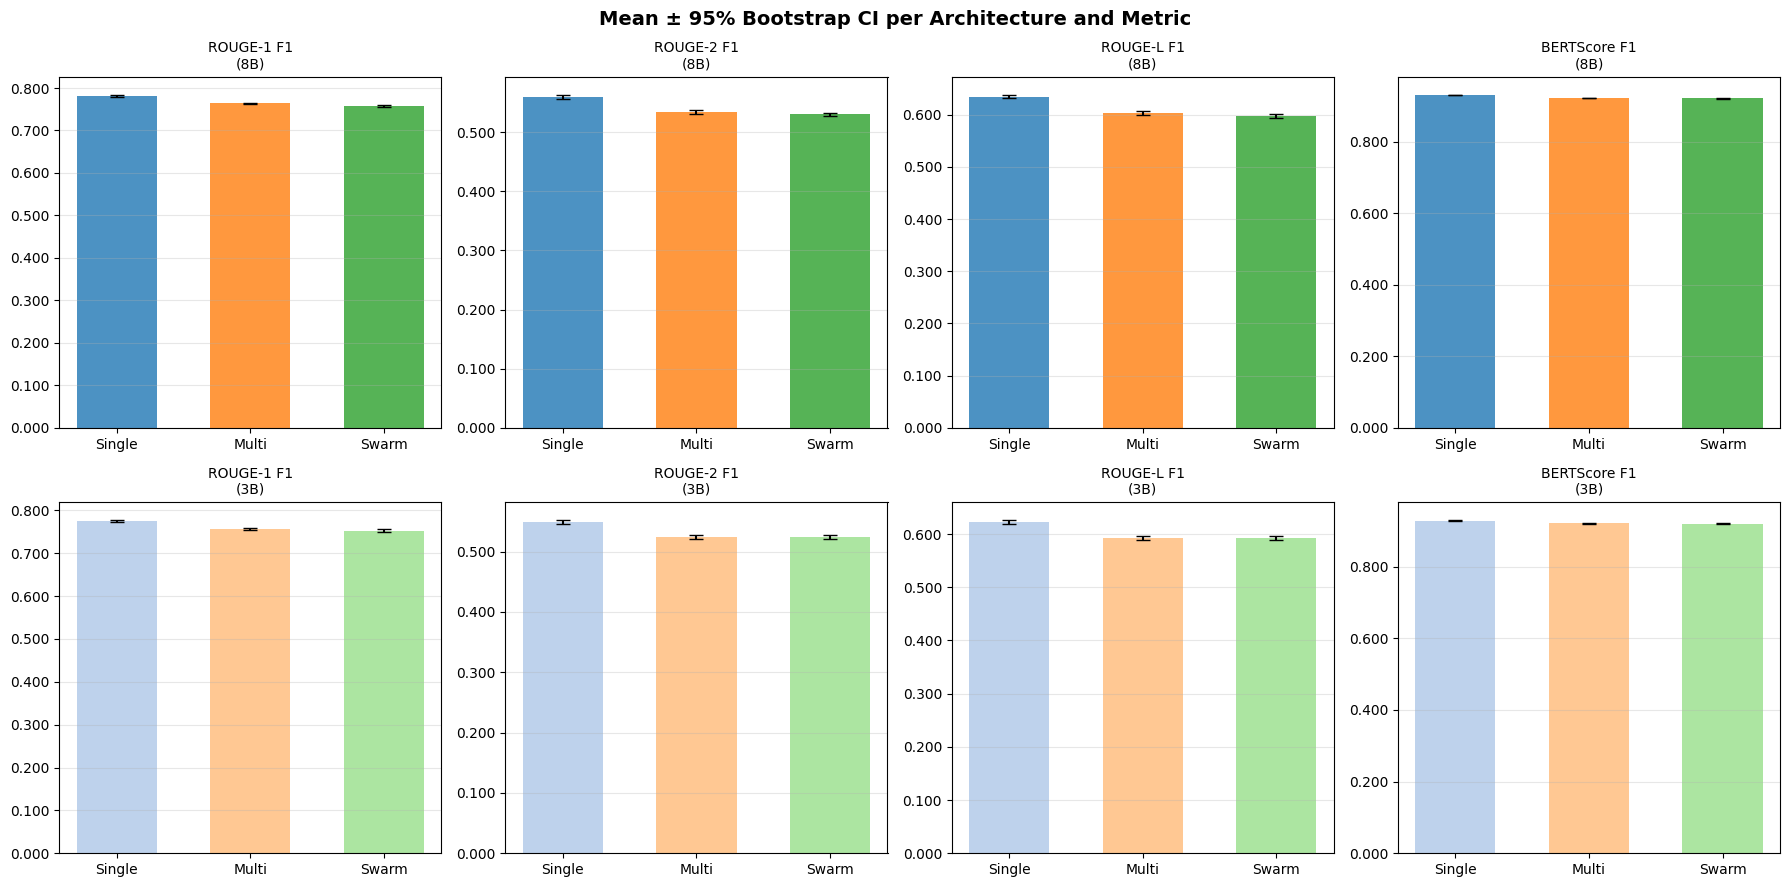

Saved: statistical_analysis_ci.png


In [17]:
MODELS_8B = ['Single-8B', 'Multi-8B', 'Swarm-8B']
MODELS_3B = ['Single-3B', 'Multi-3B', 'Swarm-3B']
COLORS = {'Single-8B': '#1f77b4', 'Multi-8B': '#ff7f0e', 'Swarm-8B': '#2ca02c',
          'Single-3B': '#aec7e8', 'Multi-3B': '#ffbb78', 'Swarm-3B': '#98df8a'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
fig.suptitle('Mean ± 95% Bootstrap CI per Architecture and Metric', fontsize=14, fontweight='bold')

for row_idx, model_group in enumerate([MODELS_8B, MODELS_3B]):
    size_label = '8B' if row_idx == 0 else '3B'
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        x_pos = np.arange(len(model_group))
        for xi, model in enumerate(model_group):
            mean, lo, hi = bootstrap_ci(dfs[model][metric])
            ax.bar(xi, mean, color=COLORS[model], alpha=0.8, width=0.6)
            ax.errorbar(xi, mean, yerr=[[mean - lo], [hi - mean]],
                        fmt='none', color='black', capsize=5, linewidth=1.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([m.replace(f'-{size_label}', '') for m in model_group], fontsize=10)
        ax.set_title(f'{METRIC_LABELS[metric]}\n({size_label})', fontsize=10)
        ax.set_ylim(ax.get_ylim()[0] * 0.98, ax.get_ylim()[1] * 1.005)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('statistical_analysis_ci.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: statistical_analysis_ci.png')

## 8. Visualisation: p-value Heatmap

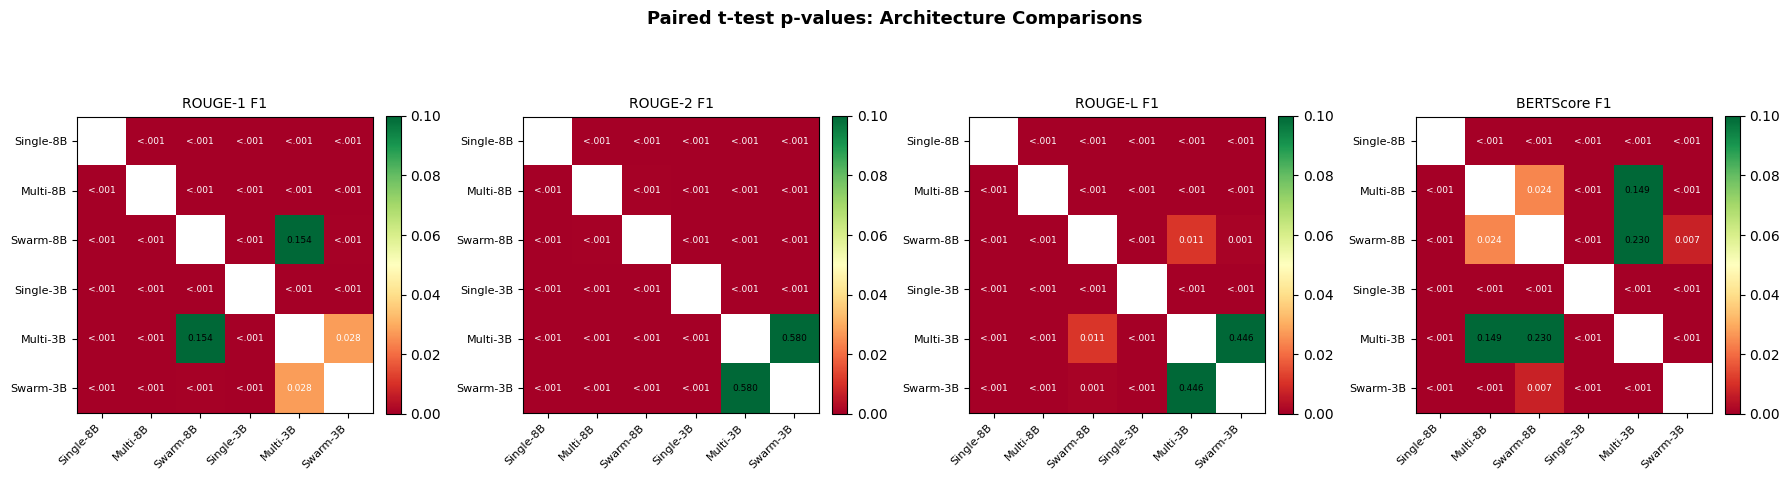

Saved: statistical_analysis_pvalues.png


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Paired t-test p-values: Architecture Comparisons', fontsize=13, fontweight='bold')

ALL_MODELS = ['Single-8B', 'Multi-8B', 'Swarm-8B', 'Single-3B', 'Multi-3B', 'Swarm-3B']
n = len(ALL_MODELS)

for ax, metric in zip(axes, METRICS):
    mat = np.full((n, n), np.nan)
    for i, a in enumerate(ALL_MODELS):
        for j, b in enumerate(ALL_MODELS):
            if i != j:
                _, p = stats.ttest_rel(dfs[a][metric], dfs[b][metric])
                mat[i, j] = p
    im = ax.imshow(mat, vmin=0, vmax=0.1, cmap='RdYlGn')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(ALL_MODELS, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ALL_MODELS, fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    for i in range(n):
        for j in range(n):
            if not np.isnan(mat[i, j]):
                txt = f'{mat[i,j]:.3f}' if mat[i,j] >= 0.001 else '<.001'
                ax.text(j, i, txt, ha='center', va='center', fontsize=6.5,
                        color='black' if mat[i,j] > 0.03 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('statistical_analysis_pvalues.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: statistical_analysis_pvalues.png')

## 9. Distribution of Per-Case Differences (Single-8B vs Swarm-8B)

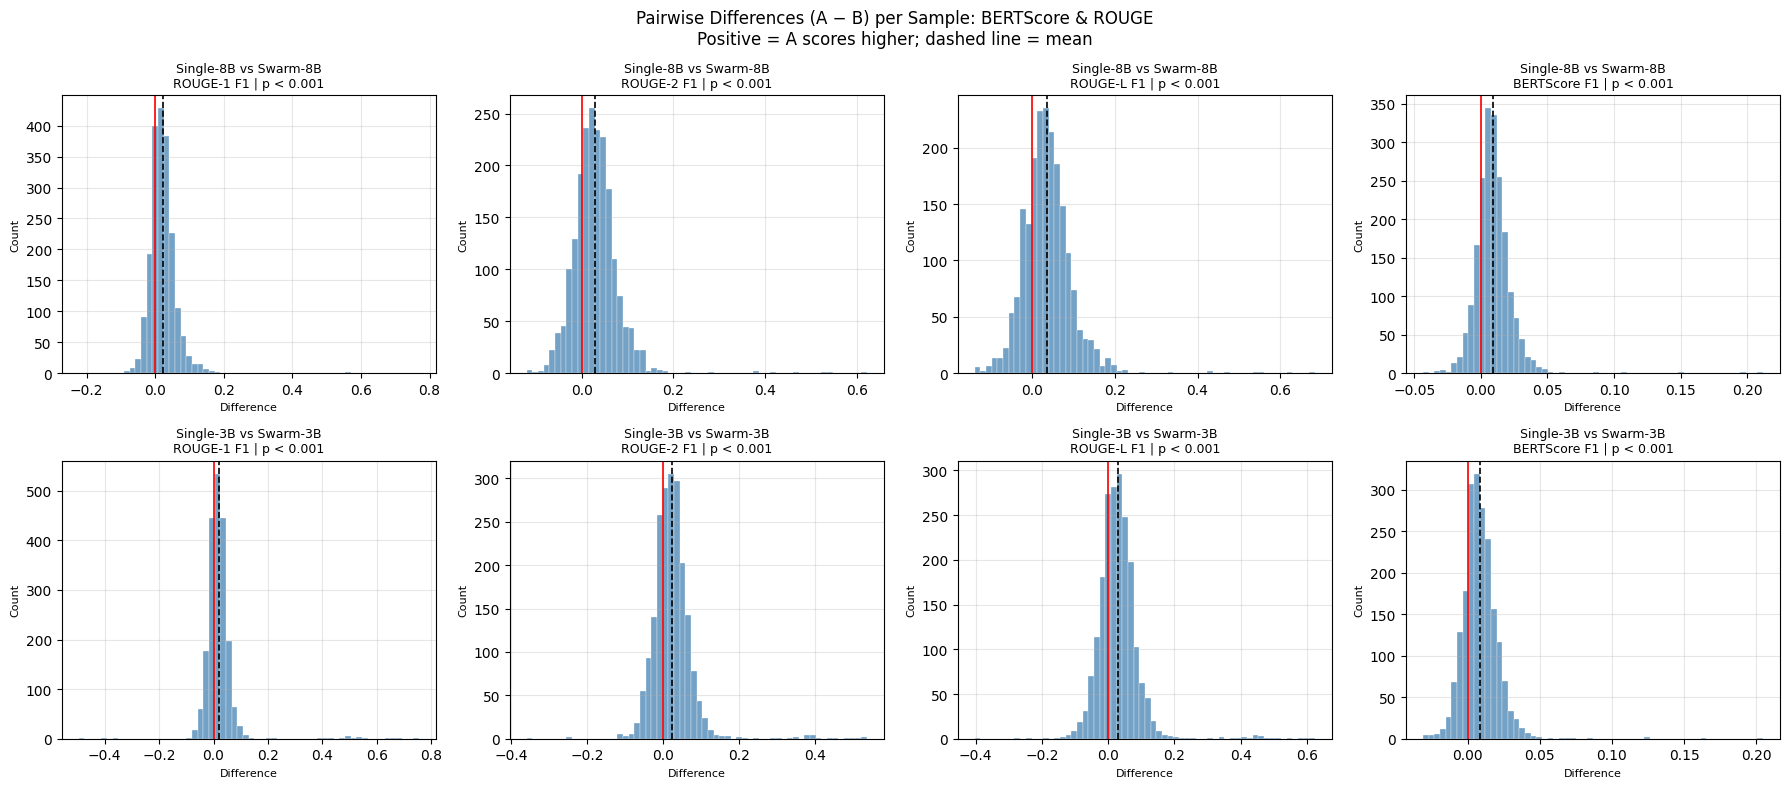

Saved: statistical_analysis_diffs.png


In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Pairwise Differences (A − B) per Sample: BERTScore & ROUGE\n'
             'Positive = A scores higher; dashed line = mean', fontsize=12)

comparisons = [
    ('Single-8B', 'Swarm-8B'),
    ('Single-3B', 'Swarm-3B'),
]

for row, (a, b) in enumerate(comparisons):
    for col, metric in enumerate(METRICS):
        ax = axes[row, col]
        diff = dfs[a][metric].values - dfs[b][metric].values
        ax.hist(diff, bins=60, color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.3)
        ax.axvline(0, color='red', linewidth=1.2, linestyle='-')
        ax.axvline(diff.mean(), color='black', linewidth=1.2, linestyle='--')
        _, p = stats.ttest_rel(dfs[a][metric], dfs[b][metric])
        sig_str = f'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
        ax.set_title(f'{a} vs {b}\n{METRIC_LABELS[metric]} | {sig_str}', fontsize=9)
        ax.set_xlabel('Difference', fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('statistical_analysis_diffs.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: statistical_analysis_diffs.png')

## 10. Summary Table for Paper

In [20]:
summary_pairs = [
    ('Single-8B', 'Multi-8B'),
    ('Single-8B', 'Swarm-8B'),
    ('Multi-8B',  'Swarm-8B'),
    ('Single-3B', 'Multi-3B'),
    ('Single-3B', 'Swarm-3B'),
    ('Multi-3B',  'Swarm-3B'),
    ('Single-8B', 'Single-3B'),
    ('Multi-8B',  'Multi-3B'),
    ('Swarm-8B',  'Swarm-3B'),
]

rows = []
for (a, b) in summary_pairs:
    row = {'Comparison': f'{a} vs {b}'}
    for metric in METRICS:
        t, p = stats.ttest_rel(dfs[a][metric], dfs[b][metric])
        delta = dfs[a][metric].mean() - dfs[b][metric].mean()
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        row[f'{METRIC_LABELS[metric]} Δ'] = f'{delta:+.4f} ({sig})'
    rows.append(row)

summary_table = pd.DataFrame(rows).set_index('Comparison')
print(summary_table.to_string())
print("\n*** p<0.001  ** p<0.01  * p<0.05  ns not significant")

                         ROUGE-1 F1 Δ   ROUGE-2 F1 Δ   ROUGE-L F1 Δ BERTScore F1 Δ
Comparison                                                                        
Single-8B vs Multi-8B   +0.0181 (***)  +0.0258 (***)  +0.0312 (***)  +0.0085 (***)
Single-8B vs Swarm-8B   +0.0240 (***)  +0.0299 (***)  +0.0376 (***)  +0.0092 (***)
Multi-8B vs Swarm-8B    +0.0059 (***)  +0.0041 (***)  +0.0064 (***)    +0.0007 (*)
Single-3B vs Multi-3B   +0.0186 (***)  +0.0237 (***)  +0.0290 (***)  +0.0073 (***)
Single-3B vs Swarm-3B   +0.0220 (***)  +0.0244 (***)  +0.0302 (***)  +0.0086 (***)
Multi-3B vs Swarm-3B      +0.0034 (*)   +0.0007 (ns)   +0.0012 (ns)  +0.0013 (***)
Single-8B vs Single-3B  +0.0075 (***)  +0.0114 (***)  +0.0126 (***)  +0.0015 (***)
Multi-8B vs Multi-3B    +0.0080 (***)  +0.0093 (***)  +0.0104 (***)   +0.0004 (ns)
Swarm-8B vs Swarm-3B    +0.0054 (***)  +0.0060 (***)   +0.0051 (**)   +0.0009 (**)

*** p<0.001  ** p<0.01  * p<0.05  ns not significant


## 11. Final Copy-Paste Statements for Paper (Reviewer 3)

In [21]:
print("=" * 80)
print("COPY-PASTE STATEMENTS FOR RESULTS SECTION")
print("=" * 80)
print()

focal = [
    ('Single-8B', 'Multi-8B',  'bertscore', 'BERTScore F1'),
    ('Single-8B', 'Swarm-8B',  'bertscore', 'BERTScore F1'),
    ('Multi-8B',  'Swarm-8B',  'bertscore', 'BERTScore F1'),
    ('Single-8B', 'Swarm-8B',  'rouge1',    'ROUGE-1 F1'),
    ('Single-8B', 'Swarm-8B',  'rouge2',    'ROUGE-2 F1'),
    ('Single-3B', 'Swarm-3B',  'bertscore', 'BERTScore F1'),
    ('Single-8B', 'Single-3B', 'bertscore', 'BERTScore F1'),
    ('Swarm-8B',  'Swarm-3B',  'bertscore', 'BERTScore F1'),
]

for (a, b, mk, ml) in focal:
    print(paper_statement(a, b, mk, ml))
    print()

COPY-PASTE STATEMENTS FOR RESULTS SECTION

Single-8B achieves higher BERTScore F1 (0.9300) than Multi-8B (0.9215), a statistically significant difference (paired t-test, p < 0.001).

Single-8B achieves higher BERTScore F1 (0.9300) than Swarm-8B (0.9208), a statistically significant difference (paired t-test, p < 0.001).

Multi-8B achieves higher BERTScore F1 (0.9215) than Swarm-8B (0.9208), a statistically significant difference (paired t-test, p = 0.024).

Single-8B achieves higher ROUGE-1 F1 (0.7818) than Swarm-8B (0.7577), a statistically significant difference (paired t-test, p < 0.001).

Single-8B achieves higher ROUGE-2 F1 (0.5600) than Swarm-8B (0.5301), a statistically significant difference (paired t-test, p < 0.001).

Single-3B achieves higher BERTScore F1 (0.9284) than Swarm-3B (0.9199), a statistically significant difference (paired t-test, p < 0.001).

Single-8B achieves higher BERTScore F1 (0.9300) than Single-3B (0.9284), a statistically significant difference (paired t-